In [2]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

with open("../data/processed/processed_resumes.json") as f:
    resumes = json.load(f)

df = pd.DataFrame(resumes)
print(df.shape)
print(df['category'].unique())
df.head()

(2484, 9)
<StringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str


,filename,raw_text,email,phone,skills,experience_years,education,skill_count,category
0,resume_0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,,,"[c, data analysis, aws]",15,diploma,3,HR
1,resume_1,"HR SPECIALIST, US HR OPERATIONS ...",,,"[c, git]",0,bachelor,2,HR
2,resume_2,HR DIRECTOR Summary Over 2...,,,"[c, excel, express]",20,bachelor,3,HR
3,resume_3,HR SPECIALIST Summary Dedica...,,,"[c, excel]",0,not specified,2,HR
4,resume_4,HR MANAGER Skill Highlights ...,,,"[c, llm, excel, aws]",0,bachelor,4,HR


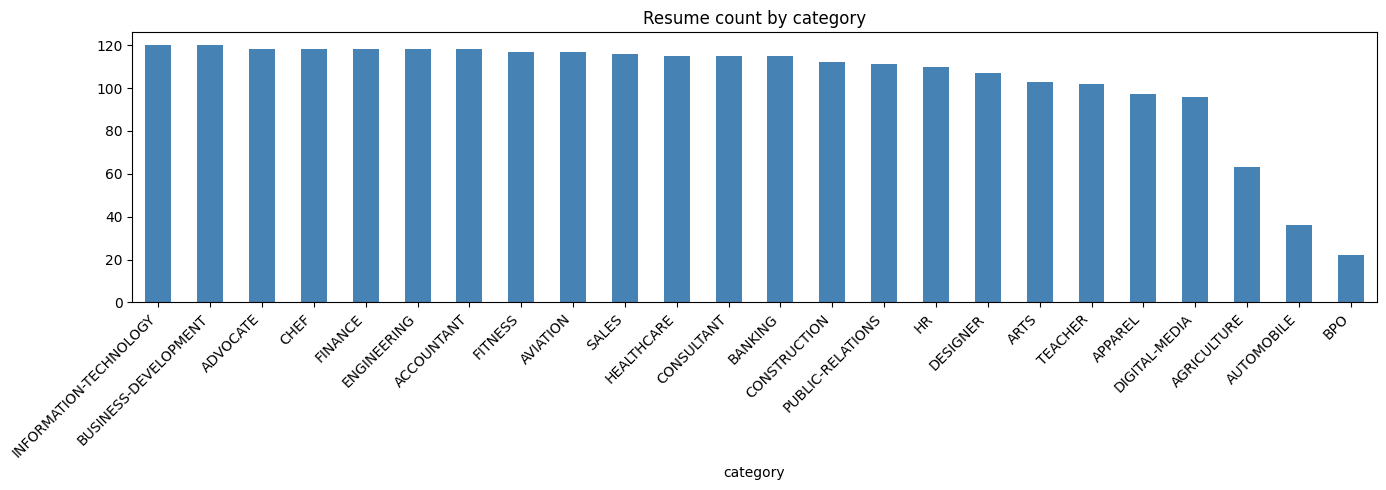

In [3]:
plt.figure(figsize=(14, 5))
df['category'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Resume count by category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../reports/category_distribution.png")
plt.show()

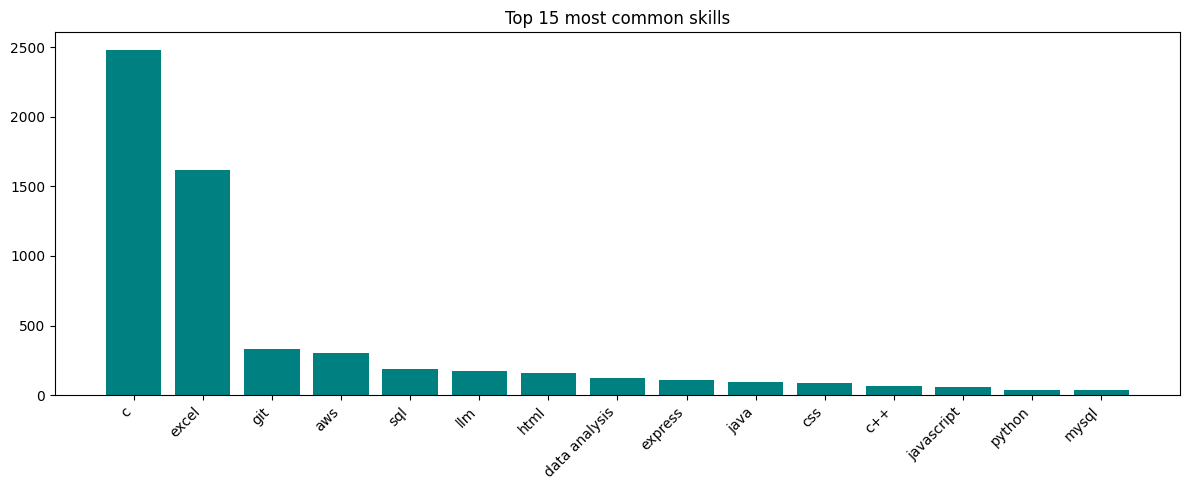

In [4]:
all_skills = []
for skills in df['skills']:
    all_skills.extend(skills)

skill_counts = Counter(all_skills).most_common(15)
skills_list, counts = zip(*skill_counts)

plt.figure(figsize=(12, 5))
plt.bar(skills_list, counts, color='teal')
plt.title("Top 15 most common skills")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../reports/top_skills.png")
plt.show()

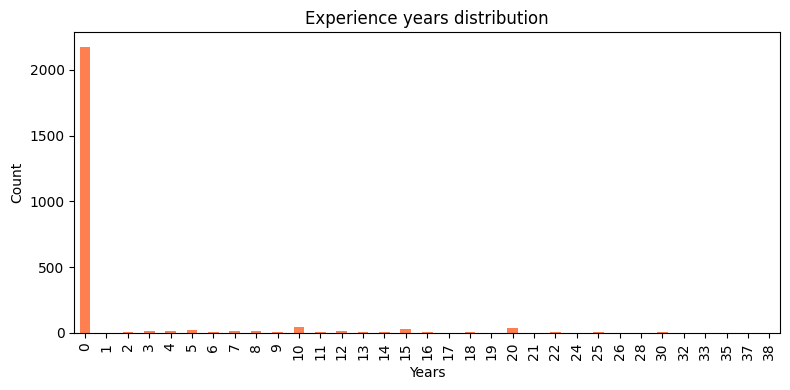

In [5]:
plt.figure(figsize=(8, 4))
df['experience_years'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title("Experience years distribution")
plt.xlabel("Years")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/experience_distribution.png")
plt.show()

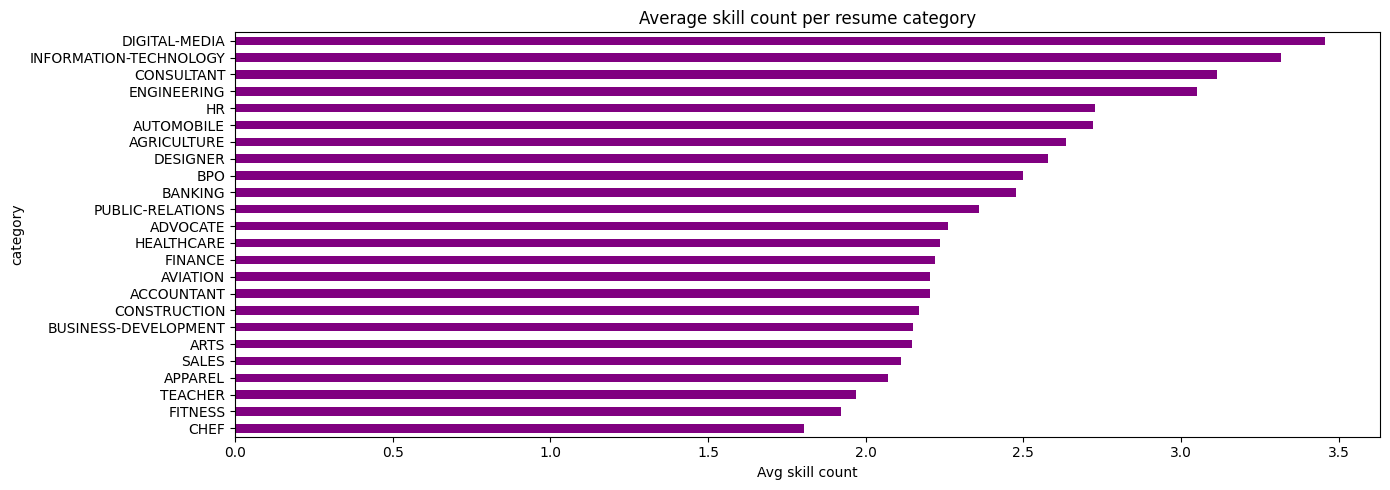

In [6]:
plt.figure(figsize=(14, 5))
df.groupby('category')['skill_count'].mean().sort_values().plot(kind='barh', color='purple')
plt.title("Average skill count per resume category")
plt.xlabel("Avg skill count")
plt.tight_layout()
plt.savefig("../reports/skills_per_category.png")
plt.show()